<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/M1_Clustering_nomad_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1: Clustering nomad cities

In this notebook we group cities from the **digital nomad** dataset (780 cities).

1. **Example 1 – Hierarchical clustering** on 7 cities, step by step
2. **Example 2 – K-means** on the same 7 cities, step by step
3. **How many clusters?** The elbow method and the silhouette score, on all 780 cities
4. **Exercise** – cluster all the data with and without PCA and compare the results

## 0. Setup

In [ ]:
import numpy as np

# Convert lists to numpy arrays before subtraction
np.linalg.norm(np.array([1.0, 1.0]) - np.array([1.0, 1.0]))

np.float64(0.0)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from ipywidgets import interact
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler

In [ ]:
cities = pd.read_csv('https://sds-aau.github.io/SDS-master/M1/data/cities.csv')
print(cities.shape)
cities.head()

(780, 25)


,place,alpha-2,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,...,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,...,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,...,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,...,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,...,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


For the two examples we use **7 cities** and **2 columns**: `safety` and `nightlife`.
Both are scores between 0 and 1, so we can use them without scaling.

In [ ]:
names = ['Copenhagen', 'Madrid', 'Budapest', 'Mexico City', 'Chiang Mai', 'Dubai', 'Kuala Lumpur']
sample = cities.set_index('place').loc[names, ['safety', 'nightlife']]
sample

,safety,nightlife
place,,
Copenhagen,1.00,1.00
Madrid,0.80,0.80
Budapest,0.60,1.00
Mexico City,0.42,1.00
Chiang Mai,0.80,0.40
Dubai,1.00,0.43
Kuala Lumpur,0.60,0.20


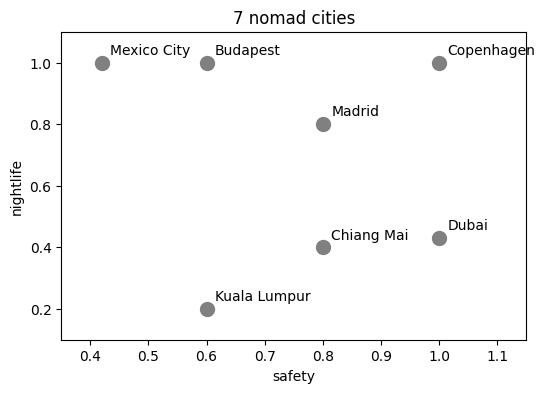

In [ ]:

def plot_cities(data, groups=None, centroids=None, title=''):
    """Scatter plot of the sample cities, coloured by group, with optional centroids."""
    plt.figure(figsize=(6, 4))
    if groups is None:
        plt.scatter(data['safety'], data['nightlife'], color='grey', s=100)
    else:
        plt.scatter(data['safety'], data['nightlife'], c=groups, cmap='coolwarm', s=100)
    for name, row in data.iterrows():
        plt.annotate(name, (row['safety'], row['nightlife']), textcoords='offset points', xytext=(6, 6))
    if centroids is not None:
        plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=350, c=range(len(centroids)),
                    cmap='coolwarm', edgecolors='black', linewidths=2, label='centroids')
        plt.legend()
    plt.xlim(0.35, 1.15)
    plt.ylim(0.1, 1.1)
    plt.xlabel('safety')
    plt.ylabel('nightlife')
    plt.title(title)
    plt.show()

plot_cities(sample, title='7 nomad cities')

## 1. Example: Hierarchical clustering

**Recipe**
1. Start: every city is its own cluster
2. Merge the two **closest** clusters
3. Repeat until only one cluster is left

### 1.1 Distance between every pair of cities
Euclidean distance: $d = \sqrt{(\text{safety}_1 - \text{safety}_2)^2 + (\text{nightlife}_1 - \text{nightlife}_2)^2}$

In [ ]:
euclidean_distances(sample)

array([[0.        , 0.28284271, 0.4       , 0.58      , 0.63245553,
        0.57      , 0.89442719],
       [0.28284271, 0.        , 0.28284271, 0.42941821, 0.4       ,
        0.42059482, 0.63245553],
       [0.4       , 0.28284271, 0.        , 0.18      , 0.63245553,
        0.69634761, 0.8       ],
       [0.58      , 0.42941821, 0.18      , 0.        , 0.71021124,
        0.81320354, 0.82      ],
       [0.63245553, 0.4       , 0.63245553, 0.71021124, 0.        ,
        0.20223748, 0.28284271],
       [0.57      , 0.42059482, 0.69634761, 0.81320354, 0.20223748,
        0.        , 0.46141088],
       [0.89442719, 0.63245553, 0.8       , 0.82      , 0.28284271,
        0.46141088, 0.        ]])

In [ ]:
dist = pd.DataFrame(euclidean_distances(sample), index=names, columns=names)
dist.round(2)

,Copenhagen,Madrid,Budapest,Mexico City,Chiang Mai,Dubai,Kuala Lumpur
Copenhagen,0.00,0.28,0.40,0.58,0.63,0.57,0.89
Madrid,0.28,0.00,0.28,0.43,0.40,0.42,0.63
Budapest,0.40,0.28,0.00,0.18,0.63,0.70,0.80
Mexico City,0.58,0.43,0.18,0.00,0.71,0.81,0.82
Chiang Mai,0.63,0.40,0.63,0.71,0.00,0.20,0.28
Dubai,0.57,0.42,0.70,0.81,0.20,0.00,0.46
Kuala Lumpur,0.89,0.63,0.80,0.82,0.28,0.46,0.00


### 1.2 Merge step by step
When a cluster has several cities, we use **average linkage**: the distance between two clusters is the
average of all distances between their members.

In [ ]:
clusters = {name: [name] for name in names}   # start: every city is its own cluster
tables = []                                    # the distance table at every step (for the heatmaps)

def cluster_distance(a, b):
    """Average linkage: mean distance between all cities in cluster a and all cities in cluster b."""
    return dist.loc[clusters[a], clusters[b]].values.mean()

step = 0
while len(clusters) > 1:
    step += 1
    # distance between every pair of clusters (saved for the heatmap)
    tables.append(pd.DataFrame({a: {b: cluster_distance(a, b) if a != b else np.nan for b in clusters}
                                for a in clusters}))
    # find the closest pair of clusters
    d, a, b = min((cluster_distance(a, b), a, b) for a, b in combinations(clusters, 2))
    # merge them into one cluster
    clusters[f'{a} + {b}'] = clusters.pop(a) + clusters.pop(b)
    print(f'Step {step}: merge [{a}] and [{b}] at distance {d:.2f}')

Step 1: merge [Budapest] and [Mexico City] at distance 0.18
Step 2: merge [Chiang Mai] and [Dubai] at distance 0.20
Step 3: merge [Copenhagen] and [Madrid] at distance 0.28
Step 4: merge [Kuala Lumpur] and [Chiang Mai + Dubai] at distance 0.37
Step 5: merge [Budapest + Mexico City] and [Copenhagen + Madrid] at distance 0.42
Step 6: merge [Kuala Lumpur + Chiang Mai + Dubai] and [Budapest + Mexico City + Copenhagen + Madrid] at distance 0.67


The distance table at every step as a **heatmap**. Darker = closer.
The **red** box is the smallest distance: that pair is merged, and the next table is one row and one column smaller.

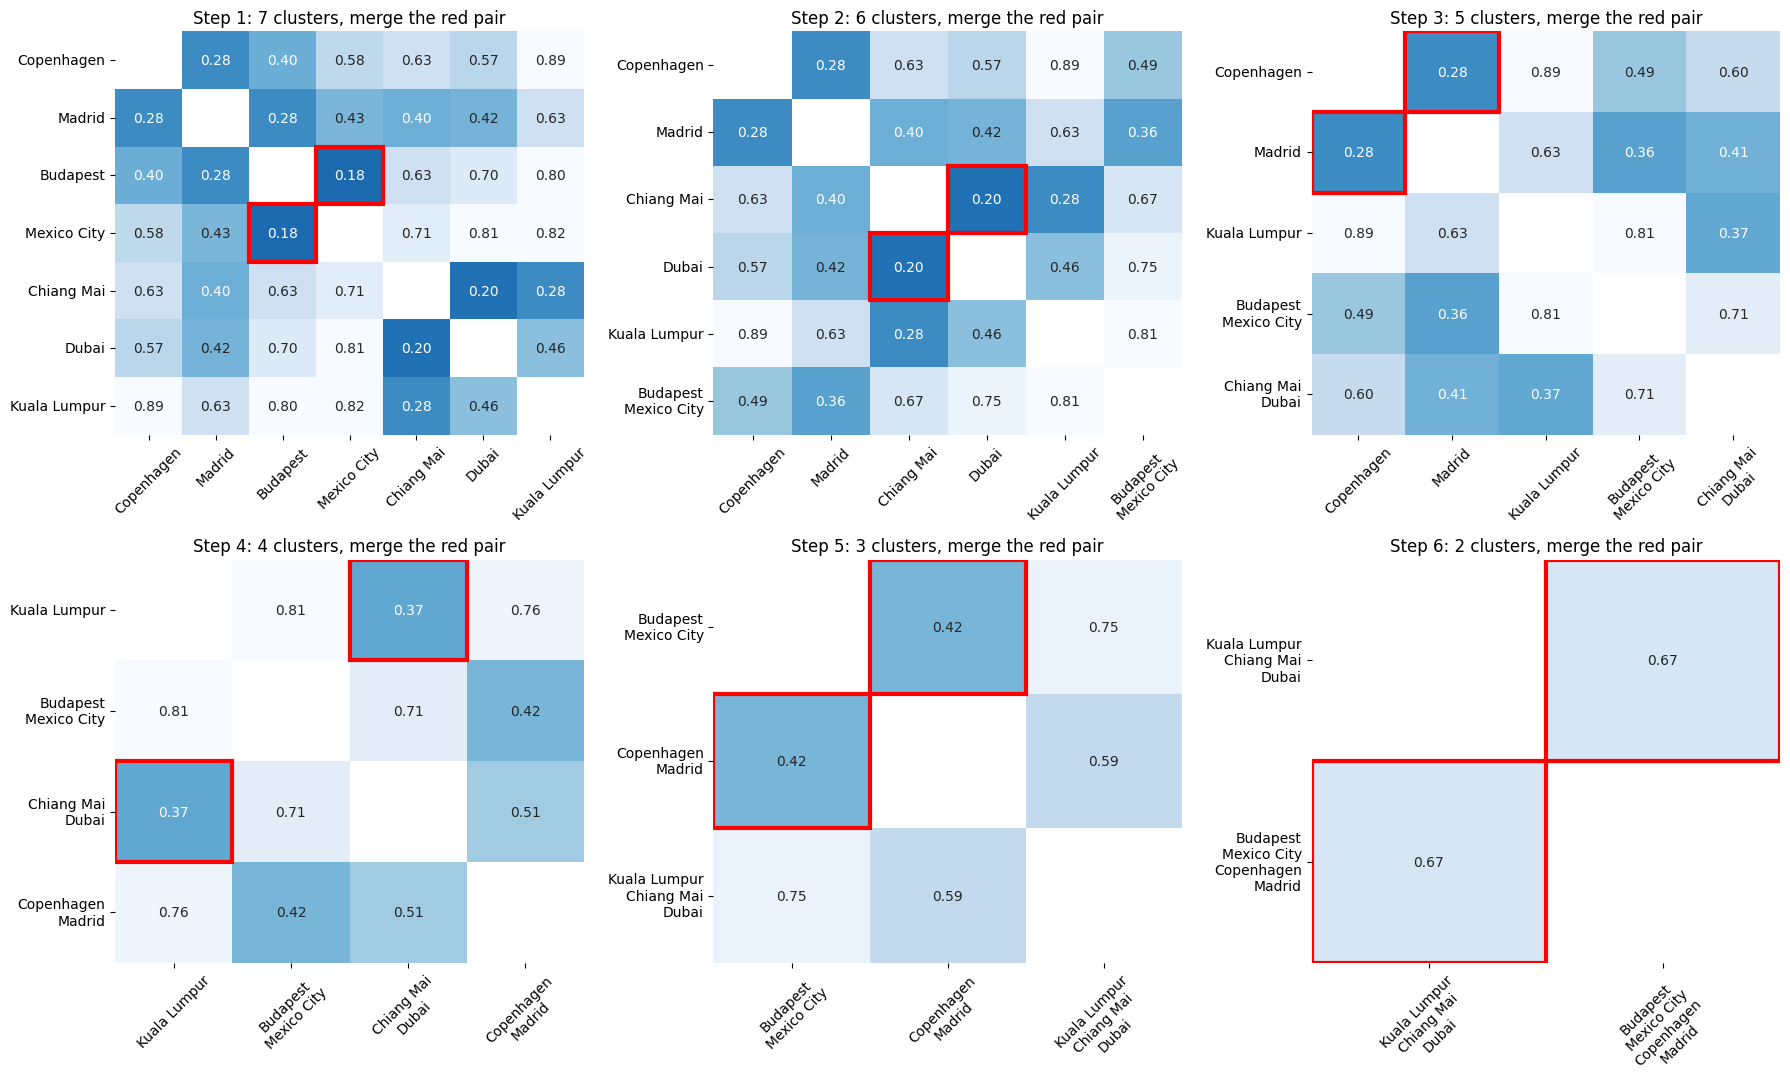

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for step, (table, ax) in enumerate(zip(tables, axes.flat), start=1):
    table = table.rename(index=lambda s: s.replace(' + ', '\n'), columns=lambda s: s.replace(' + ', '\n'))
    sns.heatmap(table, annot=True, fmt='.2f', cmap='Blues_r', vmin=0, vmax=0.8, cbar=False, ax=ax)

    # red box around the smallest distance = the pair we merge
    row, col = np.unravel_index(np.nanargmin(table.values), table.shape)
    for r, c in [(row, col), (col, row)]:
        ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor='red', lw=3))

    ax.set_title(f'Step {step}: {len(table)} clusters, merge the red pair')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 1.3 The same with scipy: the dendrogram
`linkage(..., method='average')` does the whole loop above in one line and gives the same tree.

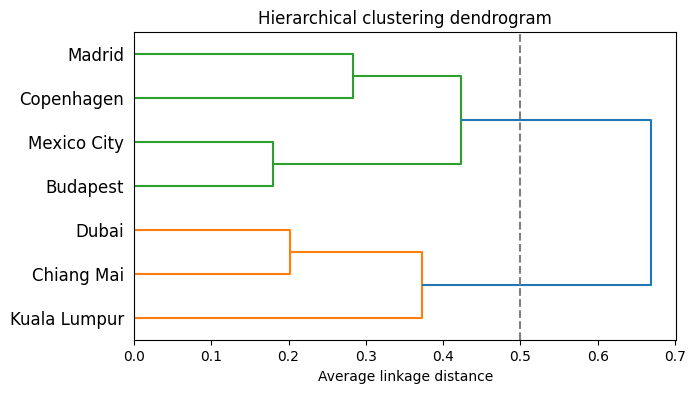

In [ ]:
Z = linkage(sample, method='average')

plt.figure(figsize=(7, 4))
dendrogram(Z, labels=names, orientation='right')
plt.axvline(0.5, color='grey', linestyle='--')   # cut here -> 2 clusters
plt.xlabel('Average linkage distance')
plt.title('Hierarchical clustering dendrogram')
plt.show()

### 1.4 Cut the tree into 2 clusters

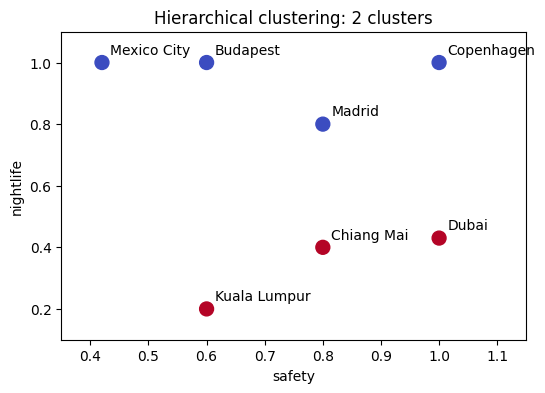

In [ ]:
hc = AgglomerativeClustering(n_clusters=2, linkage='average')
hc_groups = hc.fit_predict(sample)
plot_cities(sample, hc_groups, title='Hierarchical clustering: 2 clusters')

### 1.5 Simulation: watch the tree grow
Move the slider. Left: the cities coloured by cluster. Right: the dendrogram, with the merges done so far in **red**.
(No slider? Run for example `show_hierarchical_step(3)`.)

In [ ]:
n = len(names)

def show_hierarchical_step(step=0):
    groups = fcluster(Z, t=n - step, criterion='maxclust')   # the clusters after this step
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.scatter(sample['safety'], sample['nightlife'], c=groups, cmap='tab10', vmin=1, vmax=10, s=120)
    for name, row in sample.iterrows():
        ax1.annotate(name, (row['safety'], row['nightlife']), textcoords='offset points', xytext=(6, 6))
    ax1.set(xlabel='safety', ylabel='nightlife', title=f'Step {step}: {n - step} clusters', xlim=(0.35, 1.15), ylim=(0.1, 1.1))

    dendrogram(Z, labels=names, orientation='right', ax=ax2,
               link_color_func=lambda i: 'red' if i - n < step else 'lightgrey')
    ax2.set(xlabel='distance', title='Dendrogram (red = merged so far)')
    plt.tight_layout()
    plt.show()

interact(show_hierarchical_step, step=(0, n - 1));

interactive(children=(IntSlider(value=0, description='step', max=6), Output()), _dom_classes=('widget-interact…

## 2. Example: K-means

**Recipe** (we choose k = 2)
1. **Start:** pick k cities as the first centroids
2. **Assign:** every city joins its nearest centroid
3. **Move:** every centroid moves to the mean of its cities
4. Repeat 2 and 3 until nothing changes

### 2.1 K-means by hand
We start with a bad start on purpose (two low-nightlife cities), so we can see it improve.

Round 1
   group 0: ['Copenhagen', 'Madrid', 'Budapest', 'Mexico City', 'Chiang Mai', 'Dubai']
   group 1: ['Kuala Lumpur']
Round 2
   group 0: ['Copenhagen', 'Madrid', 'Budapest', 'Mexico City', 'Dubai']
   group 1: ['Chiang Mai', 'Kuala Lumpur']
Round 3
   group 0: ['Copenhagen', 'Madrid', 'Budapest', 'Mexico City']
   group 1: ['Chiang Mai', 'Dubai', 'Kuala Lumpur']
Round 4
   group 0: ['Copenhagen', 'Madrid', 'Budapest', 'Mexico City']
   group 1: ['Chiang Mai', 'Dubai', 'Kuala Lumpur']
Nothing changed -> stop


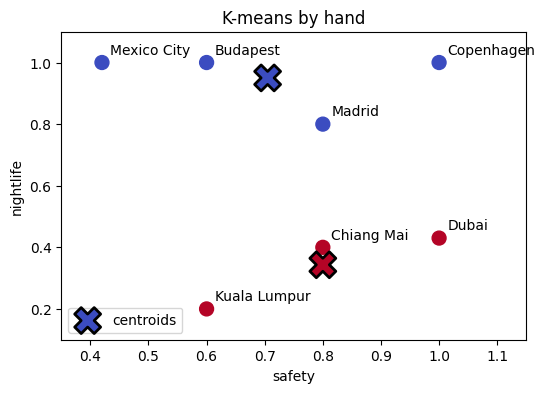

In [ ]:
k = 2
centroids = sample.loc[['Chiang Mai', 'Kuala Lumpur']].values   # start
history = []   # remember every round for the simulation below

for round_nr in range(1, 11):
    # Assign: each city goes to its nearest centroid
    groups = euclidean_distances(sample, centroids).argmin(axis=1)
    history.append((centroids, groups))

    # Move: each centroid goes to the mean of its cities
    new_centroids = np.array([sample[groups == j].mean() for j in range(k)])

    print(f'Round {round_nr}')
    for j in range(k):
        print(f'   group {j}: {list(sample.index[groups == j])}')

    if np.allclose(new_centroids, centroids):
        print('Nothing changed -> stop')
        break
    centroids = new_centroids

plot_cities(sample, groups, centroids, 'K-means by hand')

### 2.2 The same with sklearn
The group numbers (0/1) can be swapped, but the groups are the same.

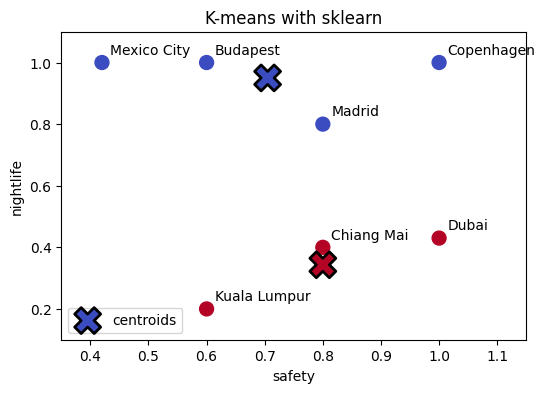

In [ ]:
km = KMeans(n_clusters=2, n_init=10, random_state=42)
km_groups = km.fit_predict(sample)
plot_cities(sample, km_groups, km.cluster_centers_, 'K-means with sklearn')

### 2.3 Simulation: watch the centroids move
Move the slider through the rounds. The **X** marks are the centroids; each city takes the colour of its nearest centroid.
(No slider? Run for example `show_kmeans_round(2)`.)

In [ ]:
def show_kmeans_round(round_nr=1):
    centroids, groups = history[round_nr - 1]
    plot_cities(sample, groups, centroids, f'Round {round_nr}: each city joins the nearest X')

interact(show_kmeans_round, round_nr=(1, len(history)));

interactive(children=(IntSlider(value=1, description='round_nr', max=4, min=1), Output()), _dom_classes=('widg…

## 3. How many clusters?

In the examples we chose 2 clusters ourselves. With real data we need a method.

- **Elbow method:** plot the *inertia* (the sum of squared distances from each city to its centroid) for different k.
  Inertia always goes down; look for the **bend** where adding clusters stops helping much.
- **Silhouette score:** for each city, compare
  $a$ = average distance to the cities in its **own** cluster and
  $b$ = average distance to the cities in the **nearest other** cluster:

$$s = \frac{b - a}{\max(a, b)}$$

  $s$ is between −1 and 1. Close to 1 = the city clearly belongs to its cluster. We pick the k with the **highest average** $s$.

### 3.1 Silhouette on the small example

In [ ]:
pd.DataFrame({'group': km_groups,
              'silhouette': silhouette_samples(sample, km_groups).round(2)}, index=names)

,group,silhouette
Copenhagen,0,0.40
Madrid,0,0.32
Budapest,0,0.59
Mexico City,0,0.49
Chiang Mai,1,0.59
Dubai,1,0.47
Kuala Lumpur,1,0.53


In [ ]:
print('Average silhouette score:', round(silhouette_score(sample, km_groups), 2))

Average silhouette score: 0.48


### 3.2 All 780 cities
Now we use **all numeric columns**. They have very different units (dollars, Mbps, scores between 0 and 1),
so we **scale** them first.

In [ ]:
numeric = cities.select_dtypes('number')
X_scaled = StandardScaler().fit_transform(numeric)

print(numeric.shape)
numeric.columns.tolist()

(780, 21)


['cost_nomad',
 'cost_coworking',
 'cost_expat',
 'coffee_in_cafe',
 'cost_beer',
 'places_to_work',
 'free_wifi_available',
 'internet_speed',
 'freedom_score',
 'peace_score',
 'safety',
 'fragile_states_index',
 'press_freedom_index',
 'female_friendly',
 'lgbt_friendly',
 'friendly_to_foreigners',
 'racism',
 'leisure',
 'life_score',
 'nightlife',
 'weed']

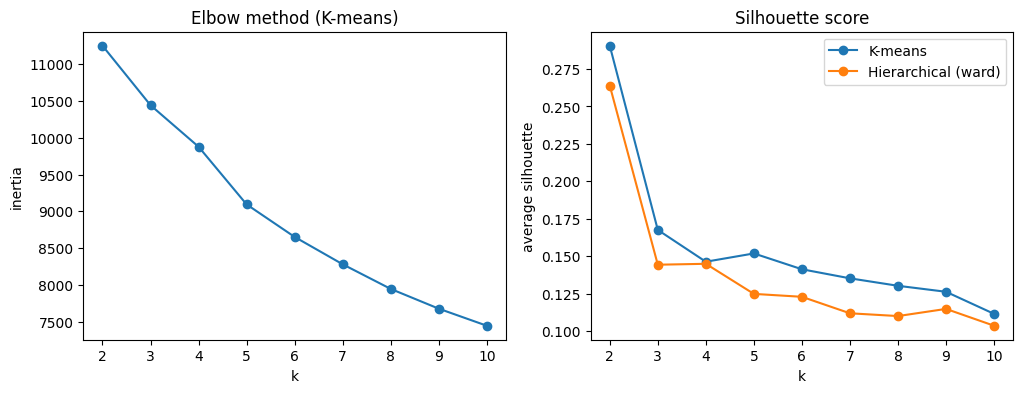

In [ ]:
ks = range(2, 11)
inertia, sil_kmeans, sil_hierarchical = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    sil_kmeans.append(silhouette_score(X_scaled, km.labels_))

    hc_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    sil_hierarchical.append(silhouette_score(X_scaled, hc_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertia, marker='o')
ax1.set(title='Elbow method (K-means)', xlabel='k', ylabel='inertia')
ax2.plot(ks, sil_kmeans, marker='o', label='K-means')
ax2.plot(ks, sil_hierarchical, marker='o', label='Hierarchical (ward)')
ax2.set(title='Silhouette score', xlabel='k', ylabel='average silhouette')
ax2.legend()
plt.show()

**How to read it:** the elbow curve has no sharp bend, so the elbow alone is hard to read.
The silhouette score is clearly **highest at k = 2** for both methods, so we choose **k = 2**.

## 4. Exercise: all data, with and without PCA

Use `X_scaled` (all 21 numeric columns, scaled) and **k = 2**.

**Part A – Without PCA**
1. Run K-means on `X_scaled`. Save the labels as `labels_raw`.
2. Print the silhouette score.

**Part B – With PCA**
1. Reduce `X_scaled` to **2 principal components** with `PCA`. Save the result as `X_pca`.
   How much of the variance do the 2 components keep? (`explained_variance_ratio_`)
2. Run K-means on `X_pca`. Save the labels as `labels_pca`.
3. Print the silhouette score (on `X_pca`).

**Part C – Compare**
1. Make a table of `labels_raw` against `labels_pca` with `pd.crosstab`. How many cities changed group?
2. Compute the `adjusted_rand_score` (1 = identical groups, 0 = random agreement).
3. Compute the silhouette score of `labels_pca` measured on `X_scaled`. Compare it with Part A.
   Why is the silhouette in Part B so much higher?
4. Plot the cities on PC1 and PC2, once coloured by `labels_raw` and once by `labels_pca`.
5. Describe the two groups: average `cost_nomad`, `internet_speed`, `safety`, `nightlife`, `freedom_score`
   per group, and the most common `region`.

*Bonus:* repeat Part C with `PCA(n_components=0.8)` (keep 80% of the variance) or with hierarchical clustering.

### Part A – Without PCA

In [ ]:
# TODO: K-means with k=2 on X_scaled -> labels_raw

# TODO: silhouette score

### Part B – With PCA

In [ ]:
# TODO: PCA with 2 components -> X_pca, and print the explained variance

# TODO: K-means with k=2 on X_pca -> labels_pca

# TODO: silhouette score on X_pca

### Part C – Compare

In [ ]:
# TODO: crosstab, adjusted rand score, silhouette of labels_pca on X_scaled

# TODO: two scatter plots on PC1 / PC2

# TODO: describe the groups

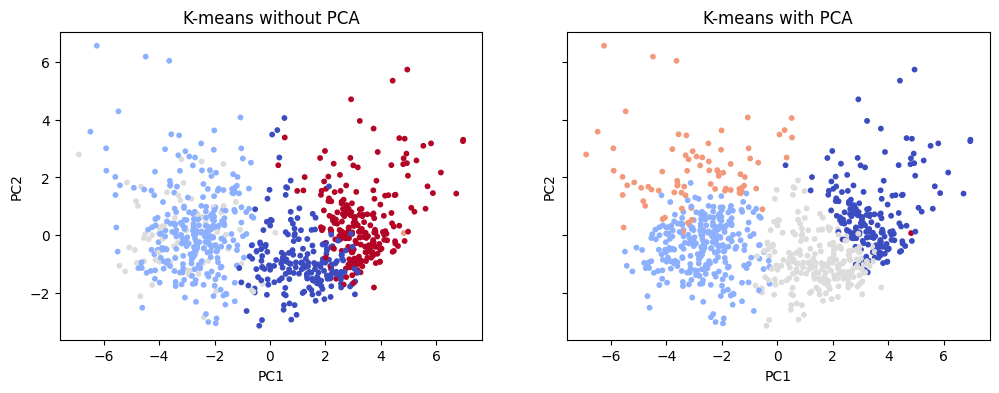

In [ ]:
#@title Solution Part C (4): plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, labels, title in zip(axes, [labels_raw, labels_pca], ['K-means without PCA', 'K-means with PCA']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', s=10)
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
plt.show()